## 1. Setup — imports, paths, and version check
Load the libraries, confirm this really is the scikit-learn 1.9.0 kernel (so the model we save later can load anywhere), and keep the file paths and column names in one place so no later cell hard-codes them.

In [1]:
# Notebook 2 — Random Forest: tuning + candidate model
# (RF is ONE candidate. Notebook 3 compares all classifiers and deploys the winner.)

import pandas as pd
import numpy as np
import sklearn
import json, time, joblib
from pathlib import Path

pd.set_option("display.max_columns", None)

print("pandas :", pd.__version__)
print("numpy  :", np.__version__)
print("sklearn:", sklearn.__version__)  

# --- config: single source of truth (paths identical to Notebook 1) ---
FEATURES_DIR = r"C:\tpot-project\04-features"
BEHAV_PATH   = FEATURES_DIR + r"\dataset_behavioral.csv"

MODELS_DIR   = r"C:\tpot-project\06-models"
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

ID_COL    = "run_id"
LABEL_COL = "label"
CLASS_ORDER  = ["scan", "online_guessing", "post_exploitation", "web_attack", "denial_of_service"]
RANDOM_STATE = 42

pandas : 2.3.3
numpy  : 2.3.5
sklearn: 1.9.0


## 2. Load the behavioral dataset
Read the 36-feature behavioral CSV into a table, then eyeball the first few rows and the class balance — every class should have exactly 30 runs.

In [2]:
df_behav = pd.read_csv(BEHAV_PATH)

print("shape:", df_behav.shape)
display(df_behav.head())

print("\nclass balance (30 each):")
print(df_behav[LABEL_COL].value_counts().reindex(CLASS_ORDER))

shape: (150, 36)


,run_id,label,total_events,duration_sec,events_per_sec,inter_event_mean,inter_event_std,burst_max_per_sec,burstiness,distinct_dest_ports,distinct_src_ports,ports_per_event,frac_on_top_port,distinct_protocols,n_login_fail,n_login_success,n_commands,n_command_failed,n_sessions,n_file_downloads,distinct_commands,n_auth_other,n_http_events,n_web_80,n_web_8080,distinct_web_paths,n_suricata_alerts,n_suricata_flows,n_alert_sev_high,n_alert_sev_info,distinct_signatures,any_login_attempt,any_login_success,any_command_run,any_file_download,any_web_request
0,B001,online_guessing,56,1.0,56.0000,0.0182,0.1336,53,1.893,1,5,0.01786,1.0,2,3,1,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0
1,B002,online_guessing,82,7.0,11.7143,0.0864,0.2810,47,4.585,1,10,0.01220,1.0,2,23,1,0,0,5,0,0,0,0,0,0,0,0,5,0,0,0,1,1,0,0,0
2,B003,online_guessing,68,6.0,11.3333,0.0896,0.4136,53,3.897,1,9,0.01471,1.0,2,11,1,0,0,5,0,0,0,0,0,0,0,0,4,0,0,0,1,1,0,0,0
3,B004,online_guessing,518,21.0,24.6667,0.0406,0.1974,62,2.633,1,46,0.00193,1.0,2,75,1,0,0,41,0,0,0,0,0,0,0,1,5,0,1,1,1,1,0,0,0
4,B005,online_guessing,694,67.0,10.3582,0.0967,0.3098,51,4.850,1,54,0.00144,1.0,2,248,1,0,0,41,0,0,0,0,0,0,0,0,14,0,0,0,1,1,0,0,0



class balance (30 each):
label
scan                 30
online_guessing      30
post_exploitation    30
web_attack           30
denial_of_service    30
Name: count, dtype: int64


## 3. Integrity check
Before training on anything, make sure there are no empty cells and no exact-duplicate runs — a duplicated run could sneak into both the training and testing side of cross-validation and quietly inflate the score.

In [3]:
# nothing should be missing, and no two runs should be identical
print("missing cells   :", int(df_behav.isna().sum().sum()))
print("duplicate rows  :", int(df_behav.duplicated().sum()))
print("duplicate run_ids:", int(df_behav[ID_COL].duplicated().sum()))

missing cells   : 0
duplicate rows  : 0
duplicate run_ids: 0


## 4. Build X and y
Split the table into the model's input (`X` = the 32 features) and the answer (`y` = the label), dropping `run_id`, `label`, and the two dead download columns. This is the exact feature list Notebook 1 used, so training and inference always line up.

In [4]:
# model features = every column EXCEPT run_id, label, and the two dead download columns.
# We drop those two BY NAME (not by a variance rule): they're all-zero except a single run,
# so a variance filter could wrongly keep them.
DROP_COLS = ["n_file_downloads", "any_file_download"]
model_features = [c for c in df_behav.columns if c not in [ID_COL, LABEL_COL, *DROP_COLS]]

X = df_behav[model_features].values
y = df_behav[LABEL_COL].values
run_ids = df_behav[ID_COL].values

print("model features:", len(model_features), "( 32)")
print("X shape:", X.shape, "| y shape:", y.shape)
print("\nfeatures in order:")
for i, c in enumerate(model_features, 1):
    print(f"  {i:2d}. {c}")

model features: 32 ( 32)
X shape: (150, 32) | y shape: (150,)

features in order:
   1. total_events
   2. duration_sec
   3. events_per_sec
   4. inter_event_mean
   5. inter_event_std
   6. burst_max_per_sec
   7. burstiness
   8. distinct_dest_ports
   9. distinct_src_ports
  10. ports_per_event
  11. frac_on_top_port
  12. distinct_protocols
  13. n_login_fail
  14. n_login_success
  15. n_commands
  16. n_command_failed
  17. n_sessions
  18. distinct_commands
  19. n_auth_other
  20. n_http_events
  21. n_web_80
  22. n_web_8080
  23. distinct_web_paths
  24. n_suricata_alerts
  25. n_suricata_flows
  26. n_alert_sev_high
  27. n_alert_sev_info
  28. distinct_signatures
  29. any_login_attempt
  30. any_login_success
  31. any_command_run
  32. any_web_request


## 5. Cross-validation and a smoke-test grid
Set up the same 5-fold stratified split we'll reuse for every model, then run GridSearch on a tiny grid first — purely to confirm the tuning machine runs and the ranked table renders before we turn it loose on the big grid. Test small, then scale.

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# 5-fold stratified CV — keeps the 30-per-class balance in every fold (same as Notebook 1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# helper: turn GridSearch results into a ranked top-N table (best mean first, then most stable)
def top_combos(grid, n=10):
    res = pd.DataFrame(grid.cv_results_)
    param_cols = [c for c in res.columns if c.startswith("param_")]
    out = (res[["mean_test_score", "std_test_score"] + param_cols]
           .sort_values(["mean_test_score", "std_test_score"], ascending=[False, True])
           .head(n).reset_index(drop=True))
    out.index = out.index + 1          # rank 1..N
    return out.round(4)

# --- SMOKE TEST: a tiny grid, just to confirm the pipeline runs ---
SMOKE_GRID = {
    "n_estimators":      [100, 200],
    "max_depth":         [None, 10],
    "min_samples_leaf":  [1, 2],
    "min_samples_split": [2],
    "max_features":      ["sqrt"],
}

# speed only (identical scores): RF single-threaded, GridSearch parallelises across settings
grid_smoke = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    SMOKE_GRID, cv=cv, scoring="accuracy", n_jobs=-1,
).fit(X, y)

print(f"smoke grid combos tried: {len(grid_smoke.cv_results_['params'])}")
print(f"best CV accuracy: {grid_smoke.best_score_:.4f}")
print(f"best params     : {grid_smoke.best_params_}")

top_combos(grid_smoke, 10)

smoke grid combos tried: 8
best CV accuracy: 0.9733
best params     : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


,mean_test_score,std_test_score,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_n_estimators
1,0.9733,0.0249,None,sqrt,1,2,100
2,0.9733,0.0249,None,sqrt,1,2,200
3,0.9733,0.0249,None,sqrt,2,2,100
4,0.9733,0.0249,None,sqrt,2,2,200
5,0.9733,0.0249,10,sqrt,1,2,100
6,0.9733,0.0249,10,sqrt,1,2,200
7,0.9733,0.0249,10,sqrt,2,2,100
8,0.9733,0.0249,10,sqrt,2,2,200


## 6. The big grid search
Now the real tuning: a large grid spanning many values of every Random Forest knob. GridSearch trains one forest per setting per fold and records each one's cross-validated accuracy. This is the slow cell — it trains thousands of forests — but it runs once and tells us which settings genuinely fit these five attack classes best.

In [6]:
# --- the big grid: many values per hyperparameter (training time is not a concern) ---
BIG_PARAM_GRID = {
    "n_estimators":      [100, 200, 300, 400, 500, 700, 1000],
    "max_depth":         [None, 5, 10, 15, 20, 30],
    "min_samples_leaf":  [1, 2, 3, 4, 6],
    "min_samples_split": [2, 5, 10],
    "max_features":      ["sqrt", "log2", None, 0.5],
    "criterion":         ["gini", "entropy"],
}

n_combos = int(np.prod([len(v) for v in BIG_PARAM_GRID.values()]))
print(f"grid size: {n_combos} settings x 5 folds = {n_combos*5} model fits")
print("training thousands of forests — this cell runs silently until it finishes...\n")

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    BIG_PARAM_GRID, cv=cv, scoring="accuracy", n_jobs=-1,
).fit(X, y)

print(f"best CV accuracy: {grid_rf.best_score_:.4f}")
print(f"best params     : {grid_rf.best_params_}")

grid size: 5040 settings x 5 folds = 25200 model fits
training thousands of forests — this cell runs silently until it finishes...

best CV accuracy: 0.9800
best params     : {'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


## 7. The top 10 settings
The ten best-scoring Random Forest configurations, ranked by cross-validated accuracy, with ties broken toward the steadier one (lower fold-to-fold wobble). We pick our RF from this shortlist next.

In [7]:
# the 10 best settings, best mean accuracy first (ties broken toward lowest std)
top_combos(grid_rf, 10)

,mean_test_score,std_test_score,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_n_estimators
1,0.98,0.0163,gini,None,None,1,2,100
2,0.98,0.0163,gini,None,None,1,2,200
3,0.98,0.0163,gini,None,None,1,2,300
4,0.98,0.0163,gini,None,None,1,2,400
5,0.98,0.0163,gini,None,None,1,2,500
6,0.98,0.0163,gini,None,None,1,2,700
7,0.98,0.0163,gini,None,None,1,2,1000
8,0.98,0.0163,gini,None,None,1,5,100
9,0.98,0.0163,gini,None,None,1,5,200
10,0.98,0.0163,gini,None,None,1,5,300


In [8]:
# the 10 best settings, best mean accuracy first (ties broken toward lowest std)
top_combos(grid_rf, 60)

,mean_test_score,std_test_score,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_n_estimators
1,0.98,0.0163,gini,None,None,1,2,100
2,0.98,0.0163,gini,None,None,1,2,200
3,0.98,0.0163,gini,None,None,1,2,300
4,0.98,0.0163,gini,None,None,1,2,400
5,0.98,0.0163,gini,None,None,1,2,500
6,0.98,0.0163,gini,None,None,1,2,700
7,0.98,0.0163,gini,None,None,1,2,1000
8,0.98,0.0163,gini,None,None,1,5,100
9,0.98,0.0163,gini,None,None,1,5,200
10,0.98,0.0163,gini,None,None,1,5,300


## 8. The tuned Random Forest + headline scores
Lock in the settings chosen from the shortlist, then measure the model honestly with 5-fold cross-validation: every run is predicted while it sits in the held-out fold, so no run is scored by a model that trained on it. We report both accuracy and macro-F1 (F1 averaged equally across the 5 classes).

In [9]:
import matplotlib.pyplot as plt
import datetime
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, f1_score)
from sklearn.inspection import permutation_importance

# the settings chosen from the top-10 shortlist (all tied at 0.980; simplest defensible point)
best_params = dict(
    criterion="gini", max_depth=None, max_features=None,
    min_samples_leaf=1, min_samples_split=2, n_estimators=300,
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf = RandomForestClassifier(**best_params)

# out-of-fold predictions for all 150 runs (each predicted while held out)
pred_cv = cross_val_predict(rf, X, y, cv=cv)

# headline scores with fold-to-fold spread
acc_folds = cross_val_score(rf, X, y, cv=cv, scoring="accuracy")
f1_folds  = cross_val_score(rf, X, y, cv=cv, scoring="f1_macro")
print(f"CV accuracy : {acc_folds.mean():.4f}  ±  {acc_folds.std():.4f}")
print(f"CV macro-F1 : {f1_folds.mean():.4f}  ±  {f1_folds.std():.4f}")
print(f"correct     : {(pred_cv == y).sum()} / {len(y)} runs")

CV accuracy : 0.9800  ±  0.0163
CV macro-F1 : 0.9799  ±  0.0164
correct     : 147 / 150 runs


## 9. Confusion matrix
Rows are the true class, columns are what the model predicted (pooled from the cross-validated predictions). A perfect model shows 30 down the diagonal; anything off-diagonal is a specific confusion worth understanding.

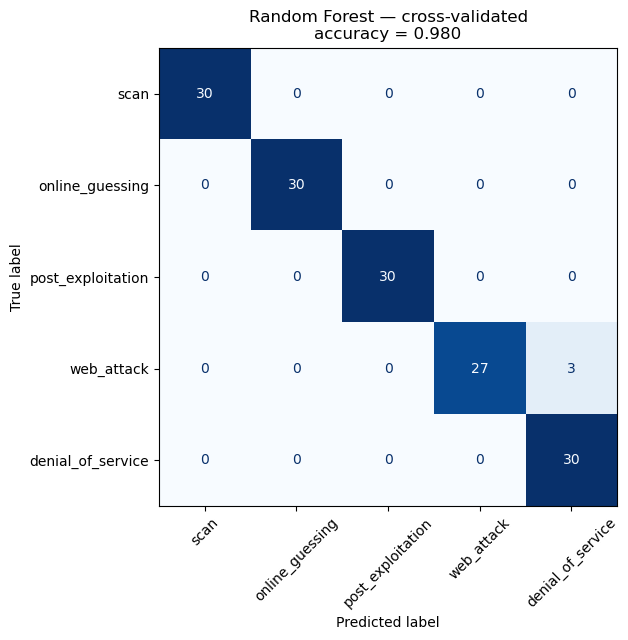

In [10]:
cm = confusion_matrix(y, pred_cv, labels=CLASS_ORDER)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER).plot(
    ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title(f"Random Forest — cross-validated\naccuracy = {(pred_cv==y).mean():.3f}")
ax.grid(False)
plt.tight_layout(); plt.show()

## 10. Per-class report
The score broken down per attack type: precision (how trustworthy each call of that type is), recall (how many real ones it caught), and F1 (the two combined). This is where you confirm no single class is quietly weak.

In [11]:
print("=== Random Forest — per-class report (cross-validated over all 150 runs) ===\n")
print(classification_report(y, pred_cv, labels=CLASS_ORDER, digits=3))

=== Random Forest — per-class report (cross-validated over all 150 runs) ===

                   precision    recall  f1-score   support

             scan      1.000     1.000     1.000        30
  online_guessing      1.000     1.000     1.000        30
post_exploitation      1.000     1.000     1.000        30
       web_attack      1.000     0.900     0.947        30
denial_of_service      0.909     1.000     0.952        30

         accuracy                          0.980       150
        macro avg      0.982     0.980     0.980       150
     weighted avg      0.982     0.980     0.980       150



## 11. Which runs did it get wrong?
Every misclassified run by ID, with its true class and the model's guess — the raw material for error analysis in the report.

In [12]:
mask = pred_cv != y
print(f"misclassified: {mask.sum()} of {len(y)} runs\n")
for rid, true_c, pred_c in sorted(zip(run_ids[mask], y[mask], pred_cv[mask])):
    print(f"   {rid}:  true = {true_c:18} ->  predicted = {pred_c}")
if mask.sum() == 0:
    print("   none — every run classified correctly.")

misclassified: 3 of 150 runs

   W001:  true = web_attack         ->  predicted = denial_of_service
   W002:  true = web_attack         ->  predicted = denial_of_service
   W003:  true = web_attack         ->  predicted = denial_of_service


## 12. Why did each misclassified run cross the boundary?
For every run the model got wrong, show its feature values beside the average of its TRUE class and its PREDICTED class. Values sitting closer to the predicted class's column explain why it was misread.

In [13]:
EXPLAIN_FEATURES = [
    "total_events", "duration_sec", "burst_max_per_sec",
    "distinct_dest_ports", "distinct_src_ports", "frac_on_top_port",
    "n_login_fail", "n_login_success", "n_auth_other", "n_commands",
    "n_web_80", "n_web_8080", "n_http_events", "distinct_web_paths",
    "n_suricata_flows", "n_suricata_alerts",
]
class_means = df_behav.groupby(LABEL_COL)[EXPLAIN_FEATURES].mean()
wrong = list(zip(run_ids[mask], y[mask], pred_cv[mask]))

if not wrong:
    print("No misclassified runs — nothing to explain.")
else:
    for rid, true_c, pred_c in sorted(wrong):
        row = df_behav.loc[df_behav[ID_COL] == rid, EXPLAIN_FEATURES].iloc[0]
        table = pd.DataFrame({
            rid:              row,
            f"avg[{true_c}]": class_means.loc[true_c],
            f"avg[{pred_c}]": class_means.loc[pred_c],
        })
        print(f"===== {rid}:  truly {true_c}  ->  predicted {pred_c} =====")
        display(table.round(1)); print()

===== W001:  truly web_attack  ->  predicted denial_of_service =====


,W001,avg[web_attack],avg[denial_of_service]
total_events,24219.0,2410.6,37964.5
duration_sec,92.0,20.4,90.3
burst_max_per_sec,821.0,86.3,3162.1
distinct_dest_ports,1.0,1.3,1.4
distinct_src_ports,2731.0,319.2,11918.5
frac_on_top_port,1.0,1.0,1.0
n_login_fail,0.0,0.0,0.0
n_login_success,0.0,0.0,0.0
n_auth_other,0.0,0.0,0.0
n_commands,0.0,0.0,0.0



===== W002:  truly web_attack  ->  predicted denial_of_service =====


,W002,avg[web_attack],avg[denial_of_service]
total_events,37742.0,2410.6,37964.5
duration_sec,96.0,20.4,90.3
burst_max_per_sec,788.0,86.3,3162.1
distinct_dest_ports,2.0,1.3,1.4
distinct_src_ports,4359.0,319.2,11918.5
frac_on_top_port,1.0,1.0,1.0
n_login_fail,0.0,0.0,0.0
n_login_success,0.0,0.0,0.0
n_auth_other,0.0,0.0,0.0
n_commands,0.0,0.0,0.0



===== W003:  truly web_attack  ->  predicted denial_of_service =====


,W003,avg[web_attack],avg[denial_of_service]
total_events,8842.0,2410.6,37964.5
duration_sec,95.0,20.4,90.3
burst_max_per_sec,704.0,86.3,3162.1
distinct_dest_ports,3.0,1.3,1.4
distinct_src_ports,2283.0,319.2,11918.5
frac_on_top_port,0.8,1.0,1.0
n_login_fail,0.0,0.0,0.0
n_login_success,0.0,0.0,0.0
n_auth_other,0.0,0.0,0.0
n_commands,0.0,0.0,0.0


## 13. Feature importance — what the model relies on
Two views. Left: the forest's built-in (Gini) importance — how much each feature helped its splits. Right: permutation importance — shuffle one feature's values and measure how much accuracy drops, a more trustworthy signal of what the model truly needs. The behavioral "fingerprint" features should dominate.

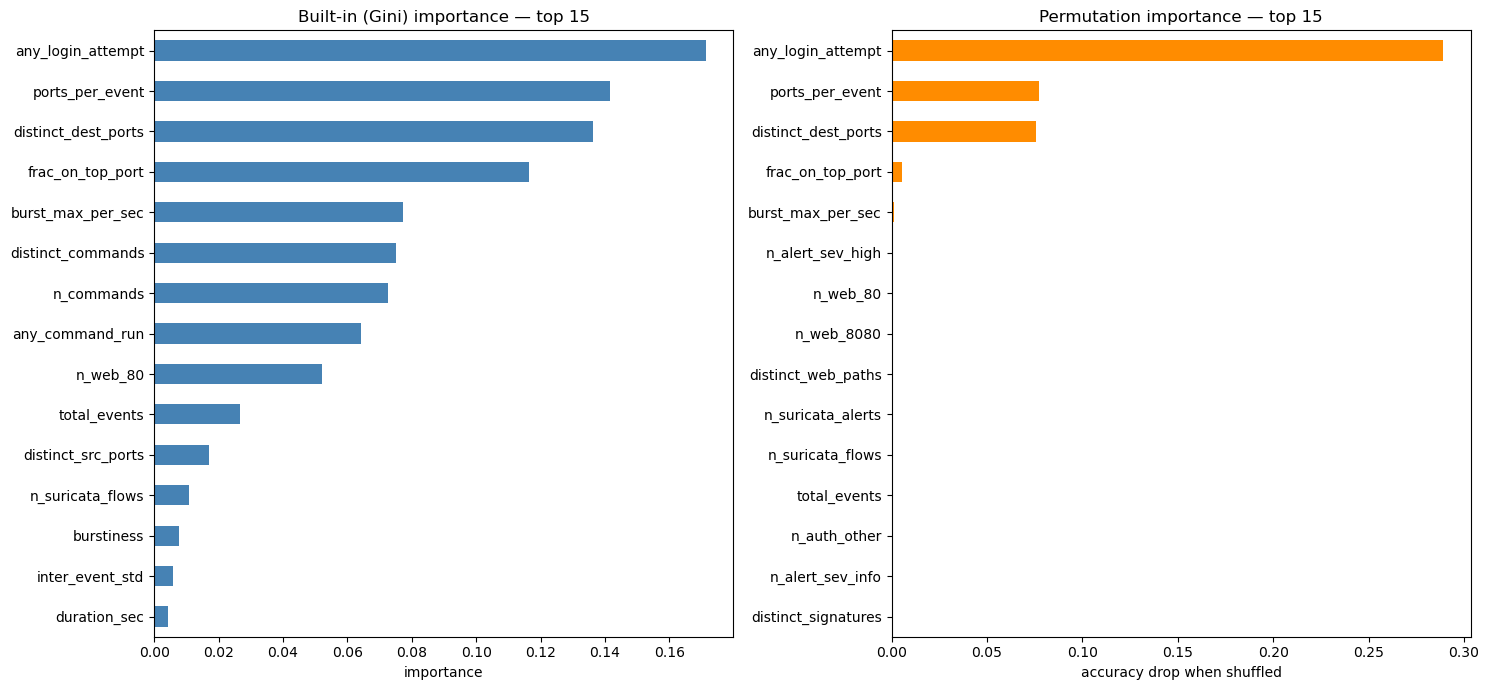

top 10 by permutation importance:
any_login_attempt      0.2890
ports_per_event        0.0770
distinct_dest_ports    0.0757
frac_on_top_port       0.0057
burst_max_per_sec      0.0013
n_alert_sev_high       0.0000
n_web_80               0.0000
n_web_8080             0.0000
distinct_web_paths     0.0000
n_suricata_alerts      0.0000
dtype: float64


In [14]:
# fit the tuned forest on all 150 rows to inspect it
rf_fit = rf.fit(X, y)

gini = pd.Series(rf_fit.feature_importances_, index=model_features).sort_values(ascending=False)
perm = permutation_importance(rf_fit, X, y, n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
perm = pd.Series(perm.importances_mean, index=model_features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
gini.head(15).iloc[::-1].plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Built-in (Gini) importance — top 15"); axes[0].set_xlabel("importance")
perm.head(15).iloc[::-1].plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("Permutation importance — top 15"); axes[1].set_xlabel("accuracy drop when shuffled")
plt.tight_layout(); plt.show()

print("top 10 by permutation importance:")
print(perm.head(10).round(4))

## 14. Train on all 150 rows and save the RF candidate
Cross-validation above measured the *recipe*. Now train one final forest on the entire dataset — the deployed candidate uses every row. Then save four files: the model, the exact 32-feature list (so inference builds its input in the same column order), the settings + metadata (including the sklearn version the pickle needs), and the full search table. The last lines reload the pickle and predict once, proving it's usable.

In [15]:
# train the final RF on ALL 150 rows (no hold-out — CV already measured the recipe)
rf_final = RandomForestClassifier(**best_params).fit(X, y)

model_path  = Path(MODELS_DIR) / "rf_model.pkl"
feat_path   = Path(MODELS_DIR) / "feature_columns.json"
params_path = Path(MODELS_DIR) / "rf_params.json"
search_path = Path(MODELS_DIR) / "rf_hyperparam_search.csv"

joblib.dump(rf_final, model_path)

# the 32 feature names IN ORDER — inference must build X with exactly these columns, same order
with open(feat_path, "w") as f:
    json.dump(model_features, f, indent=2)

meta = {
    "model": "RandomForestClassifier",
    "role": "candidate (Notebook 3 selects the deployed model)",
    "params": best_params,
    "n_features": len(model_features),
    "n_train_rows": int(len(y)),
    "cv_accuracy": round(float(acc_folds.mean()), 4),
    "cv_accuracy_std": round(float(acc_folds.std()), 4),
    "cv_macro_f1": round(float(f1_folds.mean()), 4),
    "sklearn_version": sklearn.__version__,
    "numpy_version": np.__version__,
    "saved_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds"),
}
with open(params_path, "w") as f:
    json.dump(meta, f, indent=2)

pd.DataFrame(grid_rf.cv_results_).to_csv(search_path, index=False)

print("saved:")
for p in [model_path, feat_path, params_path, search_path]:
    print("  ", p.name, f"({p.stat().st_size:,} bytes)")

# sanity: reload the model and predict one row to confirm the pickle is usable
reloaded = joblib.load(model_path)
print("\nreload check — run", run_ids[0], "predicted:", reloaded.predict(X[:1])[0], "| true:", y[0])

saved:
   rf_model.pkl (513,665 bytes)
   feature_columns.json (698 bytes)
   rf_params.json (559 bytes)
   rf_hyperparam_search.csv (1,730,947 bytes)

reload check — run B001 predicted: online_guessing | true: online_guessing
